### DECISION TREE & RANDOM FOREST

##### ️ Task 8: Coding Task — Wine Dataset (3 classes, 13 features, 178 samples): 
       a) Train DecisionTreeClassifier with max_depth=None and max_depth=3. 
          Print Train and Test accuracy for both. Observe the overfitting gap. 
       b) Train RandomForestClassifier with 50, 100, 200 n_estimators. 
          Does accuracy keep improving? Where does it plateau? 
       c) Plot the top 10 feature importances as a horizontal bar chart. 
       d) What is the OOB score? How does it compare to your test accuracy? 
  


Depth = None
Train Accuracy: 1.0
Test Accuracy : 0.9444444444444444

Depth = 3
Train Accuracy: 0.9929577464788732
Test Accuracy : 0.9444444444444444
50 Trees -> Test Accuracy = 1.0000
100 Trees -> Test Accuracy = 1.0000
200 Trees -> Test Accuracy = 1.0000


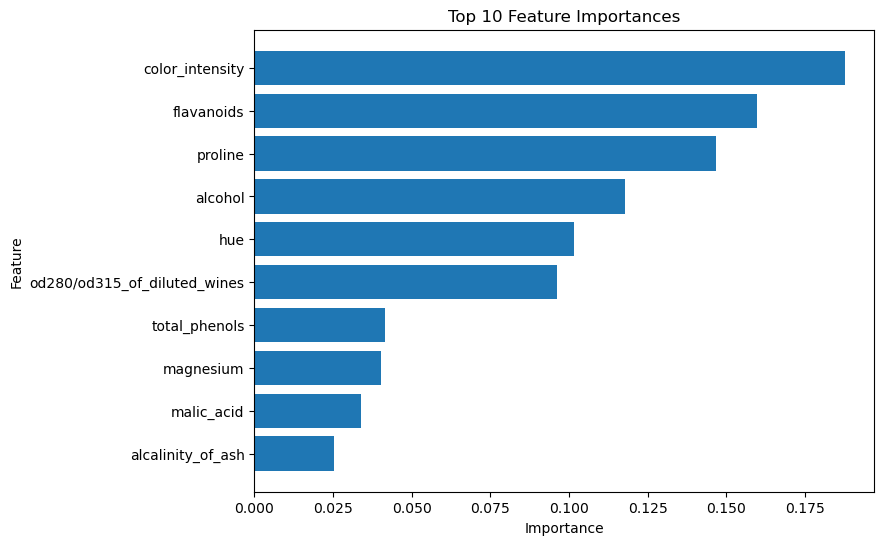

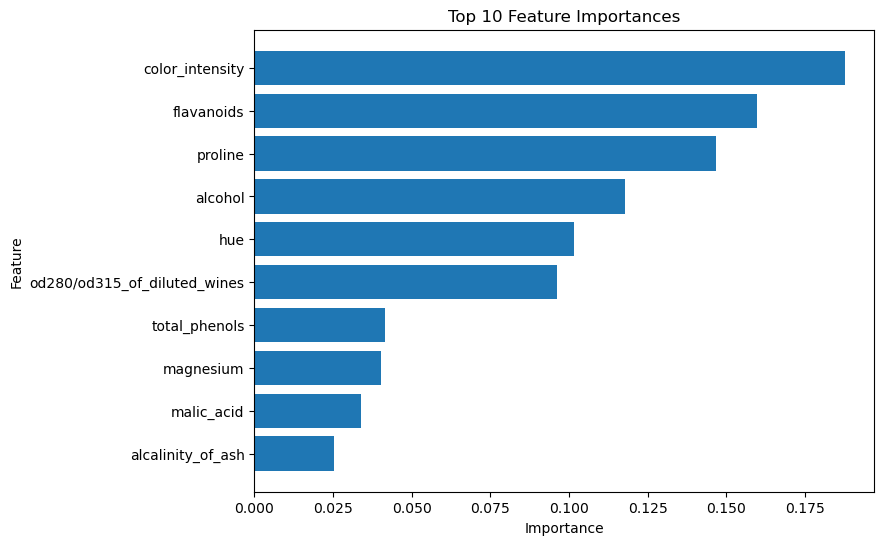

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load data
wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=42, stratify=y)

for depth in [None, 3]:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train, y_train)

    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)

    print(f"\nDepth = {depth}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)


for n in [50, 100, 200]:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train, y_train)

    test_acc = rf.score(X_test, y_test)

    print(f"{n} Trees -> Test Accuracy = {test_acc:.4f}")


rf = RandomForestClassifier( n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()

plt.show()



rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()

plt.show()

#####  Task 9: Hyperparameter Tuning Challenge: 
      
       a) Print grid.best_params_ — what is the optimal combination? 
       b) Print grid.best_score_ vs rf.score(X_test, y_test) before tuning. 
       c) Did tuning improve test accuracy? By how much? 

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Load dataset
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

baseline_acc = rf.score(X_test, y_test)

print("Baseline Test Accuracy:", baseline_acc)



param_grid = {
    'max_depth': [3,5,7,None],
    'min_samples_leaf': [1,5,10],
    'max_features': ['sqrt','log2']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)


print("Best CV Score:", grid.best_score_)
print("Baseline Test Accuracy:", baseline_acc)


best_rf = grid.best_estimator_

tuned_acc = best_rf.score(X_test, y_test)

print("Tuned Test Accuracy:", tuned_acc)

print("Improvement:",  tuned_acc - baseline_acc)



Baseline Test Accuracy: 0.956140350877193
Best Parameters:
{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Best CV Score: 0.9560439560439562
Baseline Test Accuracy: 0.956140350877193
Tuned Test Accuracy: 0.9385964912280702
Improvement: -0.01754385964912275


In [15]:
results = pd.DataFrame(grid.cv_results_)

print(results[['params', 'mean_test_score', 'rank_test_score']])


                                               params  mean_test_score  \
0   {'max_depth': 3, 'max_features': 'sqrt', 'min_...         0.951648   
1   {'max_depth': 3, 'max_features': 'sqrt', 'min_...         0.953846   
2   {'max_depth': 3, 'max_features': 'sqrt', 'min_...         0.956044   
3   {'max_depth': 3, 'max_features': 'log2', 'min_...         0.947253   
4   {'max_depth': 3, 'max_features': 'log2', 'min_...         0.953846   
5   {'max_depth': 3, 'max_features': 'log2', 'min_...         0.953846   
6   {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.949451   
7   {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.953846   
8   {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.953846   
9   {'max_depth': 5, 'max_features': 'log2', 'min_...         0.951648   
10  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.956044   
11  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.953846   
12  {'max_depth': 7, 'max_features': '